In [1]:
import json
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
# smaller font size for all plots
plt.rcParams.update({'font.size': 6}) #, 'font.family': 'serif'})

import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('../')

from omegaconf import OmegaConf

from solo.data.classification_dataloader import prepare_data
from solo.methods import METHODS
from scripts.utils.get_images_and_feats import get_images_and_feats

from sklearn.metrics import confusion_matrix
from cmcrameri import cm

In [2]:
# set up plot dir
plot_dir = Path("plots/mnist/")
plot_dir.mkdir(parents=True, exist_ok=True)

In [ ]:

dataset = "mnist"
val_data_path = "../datasets/mnist/val"
train_data_path = "../datasets/"
data_format = "image_folder"
batch_size = 256
num_workers = 4

# prepare data
train_loader, val_loader = prepare_data(
    dataset,
    train_data_path=train_data_path,
    val_data_path=val_data_path,
    data_format=data_format,
    batch_size=batch_size,
    num_workers=num_workers,
    auto_augment=False,
)

In [4]:
def load_model(model_name, run_name):
    folder_name = "../trained_models/" + model_name + "/"
    # get name of the most recent model by folder creation time
    names = sorted(os.listdir(folder_name), key=lambda x: os.path.getctime(os.path.join(folder_name, x)))
    for n in names:
        run = folder_name + n
        args_file = os.path.join(run, "args.json")
        args = json.load(open(args_file, "r"))
        if args["name"] == run_name:
            pretrained_checkpoint_dir = run
            name = n
    cfg = OmegaConf.create(args)

    # build paths
    ckpt_dir = Path(pretrained_checkpoint_dir)
    args_path = ckpt_dir / "args.json"
    ckpt_path = [ckpt_dir / ckpt for ckpt in os.listdir(ckpt_dir) if ckpt.endswith(".ckpt")][0]

    # load arguments
    with open(args_path) as f:
        method_args = json.load(f)
    cfg = OmegaConf.create(method_args)

    # build the model
    model = (
        METHODS[method_args["method"]]
        .load_from_checkpoint(ckpt_path, strict=False, cfg=cfg)
    )

    # move model to the gpu
    device = "cuda:0"
    model = model.to(device)

    # get images and features
    data, labels, z = get_images_and_feats(device, model, val_loader)
    # clip data for imshow
    data = np.clip(data, 0, 1)

    return data, labels, z, model

In [32]:
# model name is 
model_name = "catprob"
run_name = "catprob_mnist_pairs_exact_p=0.992"
data_exact, labels_exact, z_exact, model_exact = load_model(model_name, run_name)
run_name = "catprob_mnist_pairs_approx2_p=0.992"
data_approx_p09, labels_approx_p09, z_approx_p09, model_approx09 = load_model(model_name, run_name)
run_name = "catprob_mnist_pairs_approx2_p=0.8"
data_approx_p08, labels_approx_p08, z_approx_p08, model_approx08 = load_model(model_name, run_name)
run_name = "catprob_mnist_pairs_MI"
data_MI, labels_MI, z_MI, model_MI = load_model(model_name, run_name)

model_dict = {
    r"DM, $p_\theta=0.99$": (data_exact, labels_exact, z_exact, model_exact), # make sure this is last, because we will plot it in the later plots
    r"DM+MI, $p_\theta=0.99$": (data_approx_p09, labels_approx_p09, z_approx_p09, model_approx09), 
    r"DM+MI, $p_\theta=0.8$": (data_approx_p08, labels_approx_p08, z_approx_p08, model_approx08),
    r"MI": (data_MI, labels_MI, z_MI, model_MI),
}


In [33]:


predictions_dict = {}
entropies_dict = {}
for key, (data, labels, feats, model) in model_dict.items():
    predictions = np.argmax(feats, axis=1)
    entropies = -np.nansum(feats * np.log2(feats), axis=1)
    predictions_dict[key] = predictions
    entropies_dict[key] = entropies


DM, $p_\theta=0.99$
Accuracy: 0.989
DM+MI, $p_\theta=0.99$
Accuracy: 0.892
DM+MI, $p_\theta=0.8$
Accuracy: 0.989
MI
Accuracy: 0.699


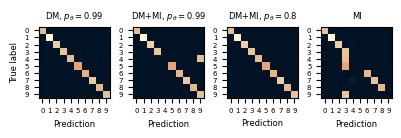

In [35]:

fig, axs = plt.subplots(1, 4, figsize=(4, 1.2))
i = 2
keys = list(entropies_dict.keys())
for i, key in enumerate(keys):
    data, labels, feats, model = model_dict[key]
    predictions = predictions_dict[key]
    entropies = entropies_dict[key]
    # make confusion matrix

    confusion = confusion_matrix(labels, predictions)

    # rearrange predictions to match labels
    labels_inds = -np.ones(np.unique(labels).shape[0], dtype=int)
    predictions_inds = -np.ones(np.unique(labels).shape[0], dtype=int)
    # get best fitting labels
    best_fits = np.dstack(np.unravel_index(np.argsort(confusion.ravel()), confusion.shape))[0][::-1]

    for j, best_fit in enumerate(best_fits): 
        l_ind, p_ind = best_fit[0], best_fit[1]
        if p_ind not in predictions_inds and l_ind not in labels_inds:
            predictions_inds[l_ind] = p_ind # replace l_ind with k for sorting
            labels_inds[l_ind] = l_ind # replace l_ind with k for sorting

    # resort feats
    predictions_inds = predictions_inds[np.argsort(labels_inds)]
    feats = feats[:, predictions_inds]
    predictions = np.argmax(feats, axis=1)

    confusion = confusion_matrix(labels, predictions)
    
    im = axs[i].imshow(confusion, cmap=cm.lipari)
    axs[i].set_xlabel("Prediction")
    axs[i].set_xticks(np.arange(10))
    axs[i].set_yticks(np.arange(10))
    #smaller font size for ticks
    axs[i].tick_params(axis='x', labelsize=5)
    axs[i].tick_params(axis='y', labelsize=5)
    print(key)
    print("Accuracy: {:.3f}".format(np.trace(confusion) / np.sum(confusion)))
    axs[i].set_title(key, fontsize=6)
    i -= 1
axs[0].set_ylabel("True label")
# plt.colorbar(im, fraction=0.03) 
plt.tight_layout()
plt.savefig(plot_dir / "mnist_confusion_matrices.pdf")

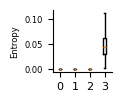

In [15]:
# plot entropy distributions
plt.figure(figsize=(1.2,1))
n = len(entropies_dict.keys())
keys = list(entropies_dict.keys())
for key in keys:
    entropies = entropies_dict[key]
    # entropies = np.log(entropies + 1e-6)  # log scale for better visibility
    plt.boxplot(entropies, positions=[list(entropies_dict.keys())[::-1].index(key)], showfliers=False)
plt.xticks(ticks=range(n), labels=range(n), rotation=0, fontsize=8)
plt.ylabel("Entropy")
# remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout() 
plt.savefig(plot_dir / "mnist_entropy_distributions.pdf")

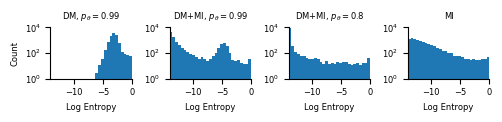

In [21]:
# plot entropy distributions
fig, ax = plt.subplots(1, 4, figsize=(5, 1.2))


n = len(entropies_dict.keys())
keys = list(entropies_dict.keys())
for i, key in enumerate(keys):
    entropies = entropies_dict[key]
    entropies = np.log(entropies + 1e-6)  # log scale for better visibility
    bins = np.linspace(-14, 0, 30)
    ax[i].hist(entropies, bins=bins)
    # remove top and right spines
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_title(key, fontsize=6)
    ax[i].set_xlabel("Log Entropy")
    ax[i].set_yscale('log')
    ax[i].set_ylim(1,10000)
    ax[i].set_xlim(-14,0)
ax[0].set_ylabel("Count")
# ax[1].spines['left'].set_visible(False)
# ax[1].set_yticks([])
# ax[2].spines['left'].set_visible(False)
# ax[2].set_yticks([])
plt.tight_layout() 
plt.savefig(plot_dir / "mnist_entropy_distributions.pdf")

In [27]:
key = r"DM, $p_\theta=0.99$"
data, labels, feats, model = model_dict[key]
predictions = predictions_dict[key]
entropies = entropies_dict[key]

confusion = confusion_matrix(labels, predictions)

# rearrange predictions to match labels
labels_inds = -np.ones(np.unique(labels).shape[0], dtype=int)
predictions_inds = -np.ones(np.unique(labels).shape[0], dtype=int)
# get best fitting labels
best_fits = np.dstack(np.unravel_index(np.argsort(confusion.ravel()), confusion.shape))[0][::-1]

for j, best_fit in enumerate(best_fits): 
    l_ind, p_ind = best_fit[0], best_fit[1]
    if p_ind not in predictions_inds and l_ind not in labels_inds:
        predictions_inds[l_ind] = p_ind # replace l_ind with k for sorting
        labels_inds[l_ind] = l_ind # replace l_ind with k for sorting

# resort feats
predictions_inds = predictions_inds[np.argsort(labels_inds)]
feats = feats[:, predictions_inds]
predictions = np.argmax(feats, axis=1)

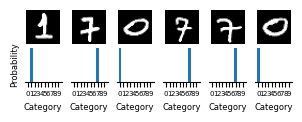

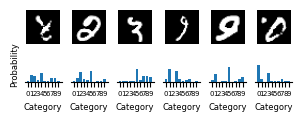

In [30]:
# plot maximum entropy images
fig, axs = plt.subplots(2, 6, figsize=(3,1.2))
# get predictions with index i
imgs = data[np.argsort(entropies)]
sort_feats = feats[np.argsort(entropies)]
for j in range(6):
    axs[0,j].imshow(imgs[j].transpose(1, 2, 0))
    axs[0,j].axis("off")
    axs[1,j].bar(range(feats.shape[1]), sort_feats[j])
    axs[1,j].set_ylim(0, 1)
    axs[1,j].set_xlim(-1, feats.shape[1])
    entropy = -np.nansum(sort_feats[j] * np.log2(sort_feats[j]))
    # axs[1,j].set_title(f"H[z]={entropy:.2f}")
    # remove y ticks
    axs[1,j].set_yticks([])
    # remove left top and right spines
    axs[1,j].spines['top'].set_visible(False)
    axs[1,j].spines['right'].set_visible(False)
    axs[1,j].spines['left'].set_visible(False)
    axs[1,j].set_xticks(range(feats.shape[1]))
    axs[1,j].set_xticklabels(range(feats.shape[1]))
    # smaller font size for x labels
    axs[1,j].tick_params(axis='x', labelsize=5)
    axs[1,j].set_xlabel("Category")
axs[1,0].set_ylabel("Probability")

plt.tight_layout()
plt.savefig(plot_dir / "mnist_max_entropy_examples.pdf")

# plot minimum entropy images
fig, axs = plt.subplots(2, 6, figsize=(3,1.2))
# get predictions with index i
imgs = data[np.argsort(entropies)[::-1]]
sort_feats = feats[np.argsort(entropies)[::-1]]
for j in range(6):
    axs[0,j].imshow(imgs[j].transpose(1, 2, 0))
    axs[0,j].axis("off")
    axs[1,j].bar(range(feats.shape[1]), sort_feats[j])
    axs[1,j].set_ylim(0, 1)
    axs[1,j].set_xlim(-1, feats.shape[1])
    entropy = -np.nansum(sort_feats[j] * np.log2(sort_feats[j]))
    # axs[1,j].set_title(f"H[z]={entropy:.2f}")
    # remove y ticks
    axs[1,j].set_yticks([])
    # remove left top and right spines
    axs[1,j].spines['top'].set_visible(False)
    axs[1,j].spines['right'].set_visible(False)
    axs[1,j].spines['left'].set_visible(False)
    axs[1,j].set_xticks(range(feats.shape[1]))
    axs[1,j].set_xticklabels(range(feats.shape[1]))
    # smaller font size for x labels
    axs[1,j].tick_params(axis='x', labelsize=5)
    axs[1,j].set_xlabel("Category")
axs[1,0].set_ylabel("Probability")

plt.tight_layout()
plt.savefig(plot_dir / "mnist_min_entropy_examples.pdf")


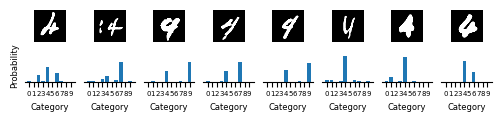

In [29]:
# plot minimum entropy images of number 4s
n = 8
fig, axs = plt.subplots(2, n, figsize=(5,1.2))
# get predictions with index i
inds = np.argsort(entropies)[::-1]
inds = inds[labels[inds] == 4]
imgs = data[inds]
sort_feats = feats[inds]
for j in range(8):
    axs[0,j].imshow(imgs[j].transpose(1, 2, 0))
    axs[0,j].axis("off")
    axs[1,j].bar(range(feats.shape[1]), sort_feats[j])
    axs[1,j].set_ylim(0, 1)
    axs[1,j].set_xlim(-1, feats.shape[1])
    entropy = -np.nansum(sort_feats[j] * np.log2(sort_feats[j]))
    # axs[1,j].set_title(f"H[z]={entropy:.2f}")
    # remove y ticks
    axs[1,j].set_yticks([])
    # remove left top and right spines
    axs[1,j].spines['top'].set_visible(False)
    axs[1,j].spines['right'].set_visible(False)
    axs[1,j].spines['left'].set_visible(False)
    axs[1,j].set_xticks(range(feats.shape[1]))
    axs[1,j].set_xticklabels(range(feats.shape[1]))
    # smaller font size for x labels
    axs[1,j].tick_params(axis='x', labelsize=5)
    axs[1,j].set_xlabel("Category")
axs[1,0].set_ylabel("Probability")

plt.tight_layout()
plt.savefig(plot_dir / "min_entropy_4s.pdf")
